# Tutorial: use all five DAP breed-prediction modes

This standalone tutorial shows how to:

1. install the repository and notebook dependencies;
2. inspect the bundled chromosome-wise Parquet files safely;
3. inspect full-length and short example SNP inputs;
4. run the pretrained Mode 1 and DAP-retrained Mode 2 examples;
5. configure all five modes through the Python API or CLI; and
6. inspect the files produced by a run.

All paths are resolved from the repository root. Modes 1 and 2 run by default,
and their saved cell outputs include logs and predictions. Modes 3-5 are
disabled by default; add their numbers to `RUN_MODES` to execute them.

Mode 1 predicts one dog with the bundled PCA and 100-output random forest. Mode
2 retrains against all eligible DAP reference dogs using the 266 SNPs shared
with the short toy input. Dog `109622` is part of the DAP training data, so both
examples demonstrate the interfaces rather than independent validation.


## 1. Locate the repository

Start Jupyter from either the repository root or `notebooks/`. The next cell
locates the repository without requiring package imports.

In [1]:
from pathlib import Path

starts = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (path for path in starts if (path / "pyproject.toml").is_file() and (path / "main.py").is_file()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Repository root not found. Clone DAP_breed_prediction and start Jupyter "
        "from the repository root or its notebooks directory."
    )

print(f"Repository detected: {REPO_ROOT.name}")

Repository detected: DAP_breed_prediction


## 2. Install the required packages

For a new checkout, the recommended terminal setup is:

```bash
git clone https://github.com/AkeyLab/DAP_breed_prediction.git
cd DAP_breed_prediction
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -e ".[tutorial]"
python -m jupyter lab notebooks/tutorial_all_modes.ipynb
```

Alternatively, set `INSTALL_PACKAGES = True` below and run the cell once. It
installs the package and Jupyter into the current kernel environment. Restart
the kernel after installation if imports were previously unavailable.


In [2]:
import shlex
import subprocess
import sys

INSTALL_PACKAGES = False
install_command = [sys.executable, "-m", "pip", "install", "-e", f"{REPO_ROOT}[tutorial]"]

if INSTALL_PACKAGES:
    subprocess.check_call(install_command, cwd=REPO_ROOT)
    print("Installation complete. Restart the kernel before continuing if needed.")
else:
    print("Installation skipped. To install, set INSTALL_PACKAGES = True.")
    print('Terminal equivalent: python -m pip install -e ".[tutorial]"')


Installation skipped. To install, set INSTALL_PACKAGES = True.
Terminal equivalent: python -m pip install -e ".[tutorial]"


In [3]:
import platform
import re
import shlex
import subprocess
import sys

import joblib
import matplotlib
import numpy as np
import pandas as pd
import polars as pl
import pyarrow
import sklearn
import yaml
from IPython.display import display
from dap_breed_prediction import run_mode

print(f"Python:        {platform.python_version()}")
print(f"pandas:        {pd.__version__}")
print(f"polars:        {pl.__version__}")
print(f"pyarrow:       {pyarrow.__version__}")
print(f"scikit-learn:  {sklearn.__version__}")

Python:        3.9.25
pandas:        2.3.3
polars:        1.36.1
pyarrow:       21.0.0
scikit-learn:  1.6.1


## 3. Check the bundled inputs

The repository contains:

- 38 chromosome-wise standardized DAP reference matrices used only by Mode 2;
- a full 54,143-SNP one-dog example for pretrained Mode 1;
- a short 266-SNP one-dog example for DAP-backed Mode 2 and saved-model Mode 3;
- labeled toy X/Y files for user-only Mode 4;
- fixed PCA-space train/test matrices for paper-reproduction Mode 5; and
- archived PCA and random-forest artifacts used by Mode 1 and figure analyses.

The checks below read file metadata rather than loading the complete DAP
reference matrix into memory.


In [4]:
DATA_DIR = REPO_ROOT / "data"
PARQUET_DIR = DATA_DIR / "folder_of_54143_SNPs"


def chromosome_number(path):
    match = re.search(r"_ch(\d+)_", path.name)
    if match is None:
        raise ValueError(f"Cannot identify chromosome number in {path.name}")
    return int(match.group(1))


parquet_files = sorted(
    PARQUET_DIR.glob("X_SNP_ch*_pruned_v3_std.parquet"),
    key=chromosome_number,
)
required_files = {
    "Full one-dog Mode 1 input": DATA_DIR / "Toy_X_full_54143_single.csv",
    "Short one-dog Mode 2/3 input": DATA_DIR / "Toy_X_single.csv",
    "Labeled Mode 4 toy genotypes": DATA_DIR / "Toy_X_snps.csv",
    "Mode 4 toy labels": DATA_DIR / "Toy_Y_labels.csv",
    "Mode 4 toy breed list": DATA_DIR / "Toy_a_short_breed_list.txt",
    "Mode 2 paper 14-breed list": DATA_DIR / "paper_14_breed_list.txt",
    "100-class labels": DATA_DIR / "y_combined_100.csv",
    "Mode 5 training PCs": DATA_DIR / "X_train_SNP_WG_prune_v3_1_std_pca_100.csv",
    "Mode 5 test PCs": DATA_DIR / "X_test_SNP_WG_prune_v3_1_std_pca_100.csv",
    "Pretrained 100-PC PCA": REPO_ROOT / "model" / "pca_model_WG_100.joblib",
    "Pretrained 100-output model": REPO_ROOT / "model" / "regressor_model0_4-PCA100.pkl",
}

if len(parquet_files) != 38:
    raise FileNotFoundError(f"Expected 38 chromosome Parquet files, found {len(parquet_files)}")
missing = [label for label, file_path in required_files.items() if not file_path.is_file()]
if missing:
    raise FileNotFoundError(f"Missing bundled inputs: {missing}")

inventory = pd.DataFrame(
    [(label, file_path.relative_to(REPO_ROOT).as_posix(), file_path.stat().st_size / 2**20)
     for label, file_path in required_files.items()],
    columns=["Input", "Repository path", "Size (MiB)"],
)
display(inventory.round({"Size (MiB)": 2}))
print(f"Chromosome Parquet files: {len(parquet_files)}")
print(f"Combined Parquet size: {sum(file_path.stat().st_size for file_path in parquet_files) / 2**20:.1f} MiB")


,Input,Repository path,Size (MiB)
0,Full one-dog Mode 1 input,data/Toy_X_full_54143_single.csv,1.99
1,Short one-dog Mode 2/3 input,data/Toy_X_single.csv,0.01
2,Labeled Mode 4 toy genotypes,data/Toy_X_snps.csv,0.26
3,Mode 4 toy labels,data/Toy_Y_labels.csv,0.00
4,Mode 4 toy breed list,data/Toy_a_short_breed_list.txt,0.00
5,Mode 2 paper 14-breed list,data/paper_14_breed_list.txt,0.00
6,100-class labels,data/y_combined_100.csv,2.55
7,Mode 5 training PCs,data/X_train_SNP_WG_prune_v3_1_std_pca_100.csv,8.36
8,Mode 5 test PCs,data/X_test_SNP_WG_prune_v3_1_std_pca_100.csv,3.61
9,Pretrained 100-PC PCA,model/pca_model_WG_100.joblib,40.18


Chromosome Parquet files: 38
Combined Parquet size: 134.9 MiB


## 4. View a Parquet file

Use Polars to inspect only the columns and rows you need. Avoid loading all 38
files and all 54,143 SNP columns merely to preview the data.

In [5]:
chromosome_rows = []
for path in parquet_files:
    schema = pl.read_parquet_schema(path)
    columns = list(schema)
    row_count = pl.scan_parquet(path).select(pl.len()).collect().item()
    chromosome_rows.append({
        "chromosome": chromosome_number(path),
        "file": path.name,
        "dogs": row_count,
        "SNP columns": len(columns) - 1,
        "size (MiB)": path.stat().st_size / 2**20,
    })

chromosome_summary = pd.DataFrame(chromosome_rows)
display(chromosome_summary.head())
print(f"Rows per file: {sorted(chromosome_summary['dogs'].unique())}")
print(f"Total SNP columns: {chromosome_summary['SNP columns'].sum():,}")
print("Use `display(chromosome_summary)` to view all 38 rows.")

,chromosome,file,dogs,SNP columns,size (MiB)
0,1,X_SNP_ch1_pruned_v3_std.parquet,7618,2137,5.296098
1,2,X_SNP_ch2_pruned_v3_std.parquet,7618,1773,4.398164
2,3,X_SNP_ch3_pruned_v3_std.parquet,7618,1785,4.427796
3,4,X_SNP_ch4_pruned_v3_std.parquet,7618,1712,4.247811
4,5,X_SNP_ch5_pruned_v3_std.parquet,7618,2135,5.286780


Rows per file: [np.int64(7618)]
Total SNP columns: 54,143
Use `display(chromosome_summary)` to view all 38 rows.


In [6]:
example_parquet = parquet_files[0]
example_schema = pl.read_parquet_schema(example_parquet)
example_snps = [column for column in example_schema if column != "dog_id"][:5]
preview_columns = ["dog_id", *example_snps]

print(f"File: {example_parquet.relative_to(REPO_ROOT)}")
print(f"Columns in this chromosome: {len(example_schema):,}")
display(pl.read_parquet(example_parquet, columns=preview_columns, n_rows=5))

File: data/folder_of_54143_SNPs/X_SNP_ch1_pruned_v3_std.parquet
Columns in this chromosome: 2,138


dog_id,chr1:5753:G:A,chr1:60406:C:T,chr1:63575:G:C,chr1:71711:A:G,chr1:99638:G:A
str,f64,f64,f64,f64,f64
"""100014""",1.24208,-1.688129,-0.130245,-1.971228,-1.670919
"""100030""",-0.221745,-0.226082,-0.130245,-0.312095,-0.032265
"""100033""",1.24208,1.235965,-0.130245,1.347038,-0.032265
"""100035""",-0.221745,-0.226082,-0.130245,1.347038,-1.670919
"""100044""",1.24208,-1.688129,-0.130245,-0.312095,-0.032265


Additional useful Polars patterns:

```python
# Schema without loading observations
schema = pl.read_parquet_schema(example_parquet)

# Select a few columns lazily
subset = (
    pl.scan_parquet(example_parquet)
    .select(["dog_id", *example_snps])
    .head(10)
    .collect()
)

# Retrieve one dog without materializing every row
one_dog = (
    pl.scan_parquet(example_parquet)
    .filter(pl.col("dog_id") == "100030")
    .select(["dog_id", *example_snps])
    .collect()
)
```

Pandas can also read Parquet with `pd.read_parquet()`. The installed `pyarrow`
dependency provides its Parquet engine and supports the pipeline's Polars-to-
pandas conversion.

## 5. Inspect the example CSV inputs

`Toy_X_full_54143_single.csv` contains the complete 54,143-SNP row required by
the pretrained Mode 1 PCA. Its values use the training-only standardization
from the paper workflow. Raw `0/1/2` genotypes cannot be passed to Mode 1
because the original fitted SNP scalers were not retained.

`Toy_X_single.csv` is the same dog copied from `Toy_X_snps.csv` with 266 SNPs,
seven from each autosome. Mode 2 finds the overlap between these columns and the
54,143 bundled DAP reference SNPs, retrains on all eligible DAP dogs, and then
predicts this row. Mode 3 can test the resulting saved model only when new X
contains that exact 266-SNP model schema.

`Toy_X_snps.csv` and `Toy_Y_labels.csv` contain 50 labeled samples for user-only
Mode 4. Every genotype CSV needs a `dog_id` column and SNP columns named
`chr<chromosome>:...`. A label CSV contains `dog_id,label`, using `BreedName`
for a pure dog or `Breed A / Breed B` for a two-breed mix.


In [7]:
full_toy_x_path = DATA_DIR / "Toy_X_full_54143_single.csv"
short_toy_x_path = DATA_DIR / "Toy_X_single.csv"
toy_x_path = DATA_DIR / "Toy_X_snps.csv"
toy_y_path = DATA_DIR / "Toy_Y_labels.csv"
breed_list_path = DATA_DIR / "Toy_a_short_breed_list.txt"
paper_breed_list_path = DATA_DIR / "paper_14_breed_list.txt"

full_header = pd.read_csv(full_toy_x_path, nrows=0)
full_preview = pd.read_csv(full_toy_x_path, usecols=list(full_header.columns[:6]))
short_header = pd.read_csv(short_toy_x_path, nrows=0)
short_preview = pd.read_csv(short_toy_x_path, usecols=list(short_header.columns[:6]))
toy_header = pd.read_csv(toy_x_path, nrows=0)
toy_preview = pd.read_csv(toy_x_path, usecols=list(toy_header.columns[:6]), nrows=5)
toy_labels = pd.read_csv(toy_y_path)
toy_breeds = [line.strip() for line in breed_list_path.read_text().splitlines() if line.strip()]
paper_breeds = [line.strip() for line in paper_breed_list_path.read_text().splitlines() if line.strip()]
all_classes = list(pd.read_csv(DATA_DIR / "y_combined_100.csv", index_col="dog_id", nrows=0).columns)

print("Full-length Mode 1 input:")
display(full_preview)
print(f"Rows: {len(pd.read_csv(full_toy_x_path, usecols=['dog_id']))}")
print(f"SNP columns: {sum(column.startswith('chr') for column in full_header.columns):,}")

print("Short Mode 2/3 input:")
display(short_preview)
print(f"Rows: {len(pd.read_csv(short_toy_x_path, usecols=['dog_id']))}")
print(f"SNP columns: {sum(column.startswith('chr') for column in short_header.columns):,}")

print("Labeled Mode 4 toy input:")
display(toy_preview)
display(toy_labels.head())
print(f"Labeled toy samples: {len(toy_labels)}")
print(f"Labeled toy SNP columns: {sum(column.startswith('chr') for column in toy_header.columns)}")
print(f"Breeds in the Mode 4 toy list: {len(toy_breeds)}")
print(f"Mode 1 output classes: {len(all_classes)} (including Unknown)")
print(f"Mode 2 targeted classes: {len(paper_breeds)}")
display(pd.DataFrame({"Paper 14-breed panel": paper_breeds}))


Full-length Mode 1 input:


,dog_id,chr1:5753:G:A,chr1:60406:C:T,chr1:63575:G:C,chr1:71711:A:G,chr1:99638:G:A
0,109622,1.24944,1.228338,-2.047649,-0.329187,-0.013223


Rows: 1
SNP columns: 54,143
Short Mode 2/3 input:


,dog_id,chr10:28623837:T:A,chr10:42424680:G:A,chr10:51884158:C:G,chr10:37569583:T:A,chr10:6233388:G:A
0,109622,-1.481878,-0.225195,1.232223,1.214075,-0.118378


Rows: 1
SNP columns: 266
Labeled Mode 4 toy input:


,dog_id,chr10:28623837:T:A,chr10:42424680:G:A,chr10:51884158:C:G,chr10:37569583:T:A,chr10:6233388:G:A
0,106610,-0.154391,1.115068,1.232223,-1.448990,-0.118378
1,109622,-1.481878,-0.225195,1.232223,1.214075,-0.118378
2,11086,1.173095,-0.225195,-0.081389,1.214075,1.198123
3,110939,-1.481878,-1.565458,1.232223,-0.117457,-0.118378
4,113788,-1.481878,-1.565458,1.232223,-0.117457,-1.434878


,dog_id,label
0,109622,Australian Shepherd
1,110939,Chinese Shar-Pei
2,113788,Siberian Husky
3,114741,German Shepherd Dog
4,116669,German Shorthaired Pointer


Labeled toy samples: 50
Labeled toy SNP columns: 266
Breeds in the Mode 4 toy list: 41
Mode 1 output classes: 100 (including Unknown)
Mode 2 targeted classes: 14


,Paper 14-breed panel
0,Australian Shepherd
1,Beagle
2,Bernese Mountain Dog
3,Border Collie
4,Boston Terrier
5,Cavalier King Charles Spaniel
6,Dachshund
7,French Bulldog
8,German Shepherd Dog
9,Golden Retriever


## 6. Python API, CLI, and execution helper

| Mode | Flags | Purpose | Main inputs |
| --- | --- | --- | --- |
| 1 | `-inference` | One-sample pretrained 100-output prediction | One full 54,143-SNP row |
| 2 | `-train -inference` | DAP-backed retraining and prediction | Short/full SNP CSV, optional class list |
| 3 | `-inference` | Saved-model multi-sample prediction or evaluation | Model, metadata, threshold, exact-schema X, optional Y |
| 4 | `-train` | Train/evaluate using only user data | User X and Y |
| 5 | `-reproduce` | Reproduce the fixed paper benchmark | Bundled PC train/test matrices |

Modes 1 and 3 share `-inference`; `prediction_model_path` in the Mode 3 YAML
distinguishes them. Set `RUN_MODES` to the modes you intentionally want to
execute. Each uses `results/tutorial_mode_<n>/`.

The notebook calls the public API:

```python
from dap_breed_prediction import run_mode
run_mode(4, config, base_dir=REPO_ROOT)
```

The CLI delegates to the same API, so both interfaces run identical validation
and pipeline code.


In [8]:
# Modes 1 and 2 execute by default so their logs remain visible on GitHub.
# Add another mode only when you intend to run it.
RUN_MODES = {1, 2}

from contextlib import redirect_stderr
from io import StringIO

MODE_FLAGS = {
    1: ["-inference"],
    2: ["-train", "-inference"],
    3: ["-inference"],
    4: ["-train"],
    5: ["-reproduce"],
}


def mode_config(mode):
    template = REPO_ROOT / "configs" / f"config_mode_{mode}_template.yml"
    with template.open() as handle:
        config = yaml.safe_load(handle) or {}
    config["result_folder_path"] = f"./results/tutorial_mode_{mode}"
    if mode == 3:
        config["prediction_model_path"] = "./results/tutorial_mode_2/Model/Prediction_model_theta_0.7.pkl"
        config["model_metadata_path"] = "./results/tutorial_mode_2/Model/model_metadata.json"
    return config


def display_inference_results(result_dir):
    predictions_path = result_dir / "Table" / "Predictions.csv"
    raw_predictions_path = result_dir / "Table" / "Raw_prediction.csv"
    log_path = result_dir / "process.log"

    if predictions_path.is_file():
        print("\nFinal inference result:")
        display(pd.read_csv(predictions_path))
    if raw_predictions_path.is_file():
        raw = pd.read_csv(raw_predictions_path).set_index("dog_id")
        top_scores = raw.iloc[0].sort_values(ascending=False).head(5).rename("score")
        print("Top five raw breed scores for the first sample:")
        display(top_scores.to_frame())
    if log_path.is_file():
        print("Inference log:")
        print(log_path.read_text().replace(str(REPO_ROOT), ".").rstrip())


def show_or_run_mode(mode):
    if mode not in MODE_FLAGS:
        raise ValueError(f"Unknown mode: {mode}")

    config = mode_config(mode)
    template_path = Path("configs") / f"config_mode_{mode}_template.yml"
    display_command = ["python", "main.py", *MODE_FLAGS[mode], "-config_path", template_path.as_posix()]

    print(f"Mode {mode} configuration:\n")
    print(yaml.safe_dump(config, sort_keys=False).rstrip())
    print(f"\nPython API:\nrun_mode({mode}, config, base_dir=REPO_ROOT)")
    print(f"\nCLI using the bundled template:\n{shlex.join(display_command)}")

    if mode not in RUN_MODES:
        print(f"\nSkipped. Add {mode} to RUN_MODES to execute this mode.")
        return None

    with redirect_stderr(StringIO()):
        result_dir = run_mode(mode, config, base_dir=REPO_ROOT)
    display_inference_results(result_dir)
    return result_dir


## 7. Mode 1: pretrained single-sample inference

Mode 1 loads the bundled PCA and 100-output random forest. It accepts exactly
one sample with all 54,143 standardized SNPs and applies the configurable
pure-versus-mixed threshold (default `0.7`). Missing or additional SNPs are
rejected; matching columns are reordered to the PCA schema when needed.

The bundled full-length example predicts dog `109622`. It was taken from the
paper training partition, so this verifies the executable inference path but is
not an independent validation result.

Required configuration: `result_folder_path`, `SNP_csv_path`. Optional settings:
`pure_threshold` (default `0.7`); the bundled model paths are fixed.


In [9]:
mode_1_result = show_or_run_mode(1)

Mode 1 configuration:

result_folder_path: ./results/tutorial_mode_1
SNP_csv_path: ./data/Toy_X_full_54143_single.csv
pure_threshold: 0.7

Python API:
run_mode(1, config, base_dir=REPO_ROOT)

CLI using the bundled template:
python main.py -inference -config_path configs/config_mode_1_template.yml



Final inference result:


,dog_id,Prediction
0,109622,Australian Shepherd


Top five raw breed scores for the first sample:


,score
Australian Shepherd,0.965
Dachshund,0.010
Bernese Mountain Dog,0.005
Labrador Retriever,0.005
Brittany,0.005


Inference log:
2026-09-10 16:04:58,367 - INFO - Running DAP breed-prediction Mode 1
2026-09-10 16:04:59,766 - INFO - Input X contains 1 sample(s) and 54,143 SNPs.
2026-09-10 16:04:59,766 - INFO - Full pretrained input requirement satisfied: 54,143 SNPs.
2026-09-10 16:04:59,766 - INFO - Loading the pretrained PCA at ./model/pca_model_WG_100.joblib
2026-09-10 16:05:02,322 - INFO - Loading the pretrained random forest at ./model/regressor_model0_4-PCA100.pkl
2026-09-10 16:05:04,688 - INFO - Using pretrained purity threshold (theta) 0.7.
2026-09-10 16:05:04,694 - INFO - Raw prediction saved to ./results/tutorial_mode_1/Table/Raw_prediction.csv
2026-09-10 16:05:04,695 - INFO - Transformed prediction saved to ./results/tutorial_mode_1/Table/Transformed_prediction.csv
2026-09-10 16:05:04,696 - INFO - Predictions (text label) saved to ./results/tutorial_mode_1/Table/Predictions.csv


## 8. Mode 2: DAP-backed retraining and prediction

Mode 2 is selected by the additional `-train` flag. It combines all eligible
labeled DAP reference samples, finds `X'` (the overlap between input SNP columns
and the complete 54,143-SNP DAP panel), optionally restricts output classes
with `breed_list_text_path`, trains a new model, saves every fitted artifact and
its metadata, and predicts the supplied row or rows.

The template has 266 requested/overlapping SNPs and 14 classes from the paper
section "Leveraging SNP importance scores to create small panels of informative
variants." Remove `breed_list_text_path` to use all 100 classes. Because the toy
dog is itself in DAP, this is a workflow demonstration rather than validation.

Required configuration: `result_folder_path`, `SNP_csv_path`. Optional settings:
`breed_list_text_path`, `include_unknown`, `pure_threshold` (default `0.7`),
`pca_components`, and `random_state`.


Mode 2 configuration:

result_folder_path: ./results/tutorial_mode_2
SNP_csv_path: ./data/Toy_X_single.csv
pure_threshold: 0.7
breed_list_text_path: ./data/paper_14_breed_list.txt
include_unknown: false

Python API:
run_mode(2, config, base_dir=REPO_ROOT)

CLI using the bundled template:
python main.py -train -inference -config_path configs/config_mode_2_template.yml



Final inference result:


,dog_id,Prediction
0,109622,Australian Shepherd


Top five raw breed scores for the first sample:


,score
Australian Shepherd,0.805
Poodle,0.040
Border Collie,0.025
Bernese Mountain Dog,0.010
Labrador Retriever,0.010


Inference log:
2026-09-10 16:05:04,734 - INFO - Running DAP breed-prediction Mode 2
2026-09-10 16:05:04,803 - INFO - Complete combined DAP reference: 6,572 samples, 100 classes, 54,143 SNPs.
2026-09-10 16:05:04,811 - INFO - The number of selected breeds is 14
2026-09-10 16:05:04,811 - INFO - Selected breed classes: ['Australian Shepherd', 'Beagle', 'Bernese Mountain Dog', 'Border Collie', 'Boston Terrier', 'Cavalier King Charles Spaniel', 'Dachshund', 'French Bulldog', 'German Shepherd Dog', 'Golden Retriever', 'Great Dane', 'Labrador Retriever', 'Pembroke Welsh Corgi', 'Poodle']
2026-09-10 16:05:04,811 - INFO - Y_train dim (2559, 14)
2026-09-10 16:05:04,828 - INFO - Input X contains 1 sample(s) and 266 requested SNPs.
2026-09-10 16:05:05,811 - INFO - The dimension of X_train is (2559, 266).
2026-09-10 16:05:05,811 - INFO - Thus, there are 2559 training samples and 266 provided SNPs are overlapped with 54,143 SNPs used in the paper.
2026-09-10 16:05:05,811 - INFO - Overlapping SNP set 

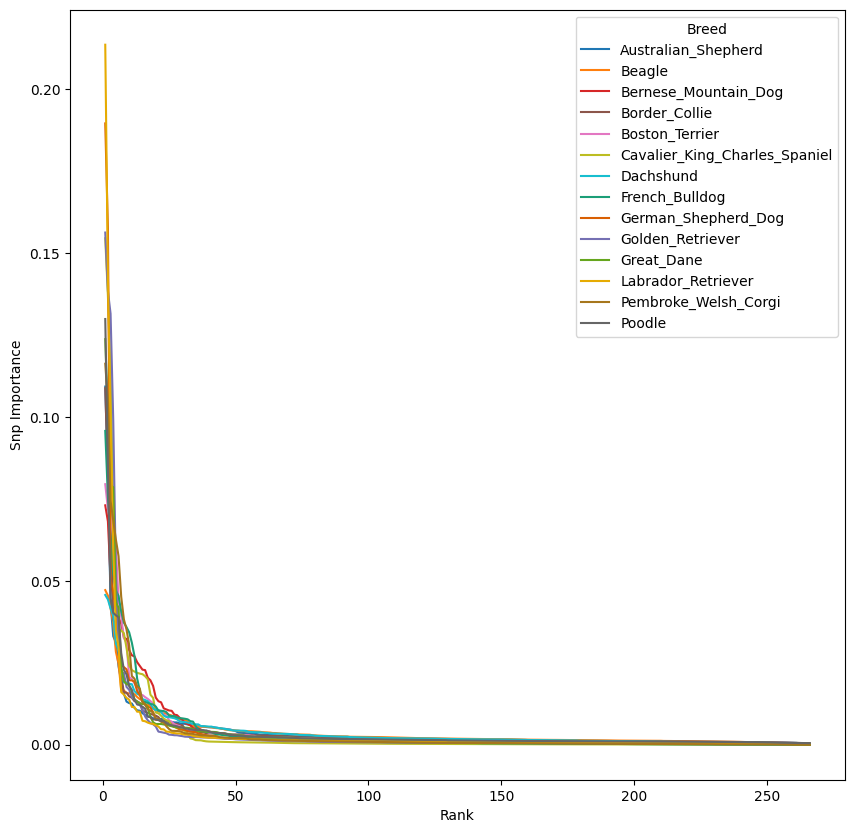

In [10]:
mode_2_result = show_or_run_mode(2)

## 9. Mode 3: saved-model prediction or performance analysis

Mode 3 requires a saved random forest, a purity threshold, model metadata, and
new X containing the exact SNP set recorded during training. It never retrains
and never reads DAP reference genotypes. With X only it performs multi-sample
prediction. Add a `label_path` CSV to calculate strict/loose accuracy and write
per-sample, per-section, per-class, and confusion-map outputs.

The template points to the CLI output from Mode 2. Inside this notebook,
`mode_config(3)` redirects it to `results/tutorial_mode_2/`. Run Mode 2 first,
then add `3` to `RUN_MODES`.

Required configuration: `result_folder_path`, `SNP_csv_path`,
`prediction_model_path`, `pure_threshold`. `model_metadata_path` is optional
only when `model_metadata.json` is beside the model; `label_path` is optional.


In [11]:
mode_3_result = show_or_run_mode(3)

Mode 3 configuration:

result_folder_path: ./results/tutorial_mode_3
prediction_model_path: ./results/tutorial_mode_2/Model/Prediction_model_theta_0.7.pkl
model_metadata_path: ./results/tutorial_mode_2/Model/model_metadata.json
SNP_csv_path: ./data/Toy_X_single.csv
pure_threshold: 0.7

Python API:
run_mode(3, config, base_dir=REPO_ROOT)

CLI using the bundled template:
python main.py -inference -config_path configs/config_mode_3_template.yml

Skipped. Add 3 to RUN_MODES to execute this mode.


## 10. Mode 4: train and evaluate on user data only

Mode 4 uses no DAP data. It reads user-provided X and Y, creates a reproducible
train/test split, optionally standardizes and applies PCA, trains a random
forest, selects the purity threshold, and evaluates held-out samples. It saves
model metadata and any fitted scaler/PCA so Mode 3 can test the resulting model.

Required configuration: `result_folder_path`, `SNP_csv_path`, `label_path`.
Optional settings: `breed_list_text_path`, `pca_components`, `random_state`,
and `test_size`.

To run the toy example, add `4` to `RUN_MODES`, execute the helper cell again,
and execute the next cell.


In [12]:
mode_4_result = show_or_run_mode(4)

Mode 4 configuration:

result_folder_path: ./results/tutorial_mode_4
SNP_csv_path: ./data/Toy_X_snps.csv
breed_list_text_path: ./data/Toy_a_short_breed_list.txt
label_path: ./data/Toy_Y_labels.csv
pca_components: 0.95
random_state: 42
test_size: 0.3

Python API:
run_mode(4, config, base_dir=REPO_ROOT)

CLI using the bundled template:
python main.py -train -config_path configs/config_mode_4_template.yml

Skipped. Add 4 to RUN_MODES to execute this mode.


## 11. Mode 5: reproduce the 100-class paper benchmark

Mode 5 replaces the former duplicate full-DAP training mode. It uses the fixed
bundled 100-PC training/test matrices and paper settings (`random_state=42`),
trains a new 100-output random forest, chooses the purity threshold on the
training set, and evaluates the fixed test set. It does not read chromosome
Parquets or load the pretrained Mode 1 random forest.

Required configuration: only `result_folder_path`. The reference run takes
approximately 4-5 minutes on CPU and reports 58.67% strict accuracy and 91.71%
loose accuracy.


In [13]:
mode_5_result = show_or_run_mode(5)


Mode 5 configuration:

result_folder_path: ./results/tutorial_mode_5

Python API:
run_mode(5, config, base_dir=REPO_ROOT)

CLI using the bundled template:
python main.py -reproduce -config_path configs/config_mode_5_template.yml

Skipped. Add 5 to RUN_MODES to execute this mode.


## 12. Inspect run outputs

Every run writes `process.log` plus `Model/`, `Table/`, and `Figure/`
directories. Prediction runs create raw scores, thresholded scores, and readable
labels. Modes 2 and 4 save `model_metadata.json`; Mode 2 also saves its exact
overlapping SNP and selected-class lists. Labeled evaluation writes strict and
loose performance metrics.

Change `MODE_TO_INSPECT` below after executing a mode.


In [14]:
MODE_TO_INSPECT = 4
result_dir = REPO_ROOT / "results" / f"tutorial_mode_{MODE_TO_INSPECT}"

if not result_dir.exists():
    print(
        f"No tutorial results found for Mode {MODE_TO_INSPECT}. "
        f"Add {MODE_TO_INSPECT} to RUN_MODES and execute its section first."
    )
else:
    produced = sorted(path.relative_to(result_dir).as_posix() for path in result_dir.rglob("*") if path.is_file())
    display(pd.DataFrame({"Produced file": produced}))

    predictions_path = result_dir / "Table" / "Predictions.csv"
    if predictions_path.is_file():
        display(pd.read_csv(predictions_path).head())

    log_path = result_dir / "process.log"
    if log_path.is_file():
        print("\nLast 15 log lines:\n")
        log_text = log_path.read_text().replace(str(REPO_ROOT), ".")
        print("\n".join(log_text.splitlines()[-15:]))

No tutorial results found for Mode 4. Add 4 to RUN_MODES and execute its section first.


## Recommended order

1. Inspect the saved Mode 1 and Mode 2 logs and predictions.
2. Run the installation and data-inspection sections.
3. Run Mode 3 after Mode 2 to test a saved model on exact-schema X.
4. Run Mode 4 to train and evaluate with only the labeled toy dataset.
5. Run Mode 5 for the fixed paper benchmark.

Training modes refit their models on every run. Use a new
`result_folder_path` when outputs from an earlier run must be retained.
